# Assignment: Trees
Do three questions.

**Q1.** Please answer the following questions in your own words.

1. How are trees constructed?

2. How do trees handle non-linear relationships between variables? Compare this to linear models. 

3. Why is the Gini a good loss function for categorical target variables? 

4. Why do trees tend to overfit, and how can this tendency be constrained? 

5. True or false, and explain: Trees only really perform well in situations with lots of categorical variables as features/covariates. 

6. Why don't most versions of classification/regression tree concept allow for more than two branches after a split?

7. What are some heuristic ways you can examine a tree and decide whether it is probably over- or under-fitting?

1. **How are trees constructed?**  
   Trees are constructed using recursive binary splitting, which divides the dataset into smaller subsets based on feature values. At each node, the algorithm selects the feature and threshold that best split the data into distinct groups, optimizing for some criterion like Gini impurity or entropy (for classification) or variance reduction (for regression). This process continues recursively, splitting data at each node until a stopping criterion is met (such as a maximum depth, minimum number of samples, or if the data in a node is pure enough).

2. **How do trees handle non-linear relationships between variables? Compare this to linear models.**  
   Trees can naturally handle non-linear relationships by recursively splitting the data into smaller groups, which can capture complex interactions and non-linear patterns between variables. Linear models, on the other hand, assume a linear relationship between features and the target, and they struggle to model interactions or non-linearities unless explicitly included as features (e.g., by adding polynomial terms).

3. **Why is the Gini a good loss function for categorical target variables?**  
   The Gini index is a good loss function for categorical target variables because it measures impurity by considering how often a randomly chosen element from the dataset would be misclassified if it were randomly labeled according to the distribution of labels in the node. It takes into account the class distribution and prefers splits that result in nodes with more homogenous class distributions, leading to better decision-making and classification accuracy.

4. **Why do trees tend to overfit, and how can this tendency be constrained?**  
   Trees tend to overfit because they can create highly complex models with deep branches that perfectly fit the training data, capturing noise and outliers rather than the underlying patterns. To constrain overfitting, we can apply techniques such as pruning (removing branches that don't improve the model), setting a maximum depth, limiting the minimum number of samples required to split a node, or requiring a minimum decrease in impurity for a split to occur.

5. **True or false, and explain: Trees only really perform well in situations with lots of categorical variables as features/covariates.**  
   **False.** Trees perform well with both categorical and continuous variables. While they naturally handle categorical data by dividing it into distinct groups, they also perform well with continuous features by selecting thresholds for splits. The power of trees lies in their ability to model complex, non-linear relationships and interactions, which can be used for both types of features.

6. **Why don't most versions of classification/regression tree concept allow for more than two branches after a split?**  
   Most versions of classification and regression trees allow only binary splits (two branches) to maintain simplicity and ensure that the tree grows in a manageable way. Binary splits help prevent the tree from becoming overly complex, which could lead to overfitting. While some tree algorithms allow multi-way splits, binary splits are favored because they ensure the tree's structure remains interpretable and reduces the risk of overfitting.

7. **What are some heuristic ways you can examine a tree and decide whether it is probably over- or under-fitting?**  
   To check for overfitting or underfitting in a tree, you can:
   - **Examine tree depth**: A very deep tree is more likely to overfit the data, while a shallow tree may underfit by not capturing enough complexity.
   - **Look at node purity**: Nodes with very low impurity (i.e., nearly all samples belong to one class) suggest overfitting.
   - **Compare training vs. testing performance**: If the model performs well on the training set but poorly on the test set, it’s likely overfitting. If performance is poor on both, the tree may be underfitting.
   - **Evaluate pruning or setting constraints**: By pruning branches or adding constraints (like limiting tree depth or requiring minimum samples per node), you can assess whether the tree improves by simplifying its structure.

**Q2.** This is a case study on regression and classification trees.

1. Load `./data/cars_hw.csv`. How many observations and features/covariates/variables? What are the available variables? Take a look at the first few rows of data.

2. For the categorical variables `Make`, `Color`, `Body_type`, `No_of_Owners`, `Fuel_Type`, `Transmission`, and `Transmission_Type`, create dummy/one-hot-encoded representations. For numeric variables, we'll use `Mileage_Run`, `Make_Year`, and `Seating_Capacity`. Our target variable will be `Price`. Make a train-test split of your data.

3. From `sklearn.tree`, import the `DecisionTreeRegressor` and `plot_tree`. Use a train-test split to iterate over possible values for `min_samples_leaf`, computing the $R^2$ for each value between 1 and 25. What choice achieves the highest $R^2$ on the test data?

4. For the optimal `min_samples_leaf` from 3, regress price on the rest of the features/covariates using the training data. What is your $R^2$ and RMSE on the test set? Plot the dendrogram. Plot the residuals. Is the density of residuals symmetric and centered around 0?

4. Run a linear regression of price on the same variables. Which model -- regression tree or linear regression -- performs better on the test set? Why?

5. Predict prices using both your tree and your linear model, and make a scatter plot of their values. Describe what you see. 

In [1]:
import pandas as pd


df = pd.read_csv('./data/cars_hw.csv')


print(f"Number of observations: {df.shape[0]}")
print(f"Number of features: {df.shape[1]}")

print("\nAvailable Variables:")
print(df.columns)


print("\nFirst few rows of the data:")
print(df.head())


Number of observations: 976
Number of features: 12

Available Variables:
Index(['Unnamed: 0', 'Make', 'Make_Year', 'Color', 'Body_Type', 'Mileage_Run',
       'No_of_Owners', 'Seating_Capacity', 'Fuel_Type', 'Transmission',
       'Transmission_Type', 'Price'],
      dtype='object')

First few rows of the data:
   Unnamed: 0        Make  Make_Year   Color  Body_Type  Mileage_Run  \
0           1  Volkswagen       2017  silver      sedan        44611   
1           2     Hyundai       2016     red  crossover        20305   
2           3       Honda       2019   white        suv        29540   
3           4     Renault       2017  bronze  hatchback        35680   
4           5     Hyundai       2017  orange  hatchback        25126   

  No_of_Owners  Seating_Capacity Fuel_Type Transmission Transmission_Type  \
0          1st                 5    diesel      7-Speed         Automatic   
1          1st                 5    petrol      5-Speed            Manual   
2          2nd         

In [ ]:
from sklearn.model_selection import train_test_split


categorical_columns = ['Make', 'Color', 'Body_Type', 'No_of_Owners', 'Fuel_Type', 'Transmission', 'Transmission_Type']
numeric_columns = ['Mileage_Run', 'Make_Year', 'Seating_Capacity']
target_column = 'Price'


df = pd.get_dummies(df, columns=categorical_columns, drop_first=True)

X = df.drop(columns=[target_column])
y = df[target_column]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import r2_score


r2_scores = []


for min_samples_leaf in range(1, 26):
    tree = DecisionTreeRegressor(min_samples_leaf=min_samples_leaf, random_state=42)
    tree.fit(X_train, y_train)

    y_pred = tree.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    r2_scores.append((min_samples_leaf, r2))


best_min_samples_leaf, best_r2 = max(r2_scores, key=lambda x: x[1])
print(f"Best min_samples_leaf: {best_min_samples_leaf} with R^2: {best_r2}")


Best min_samples_leaf: 8 with R^2: 0.8213135837522154


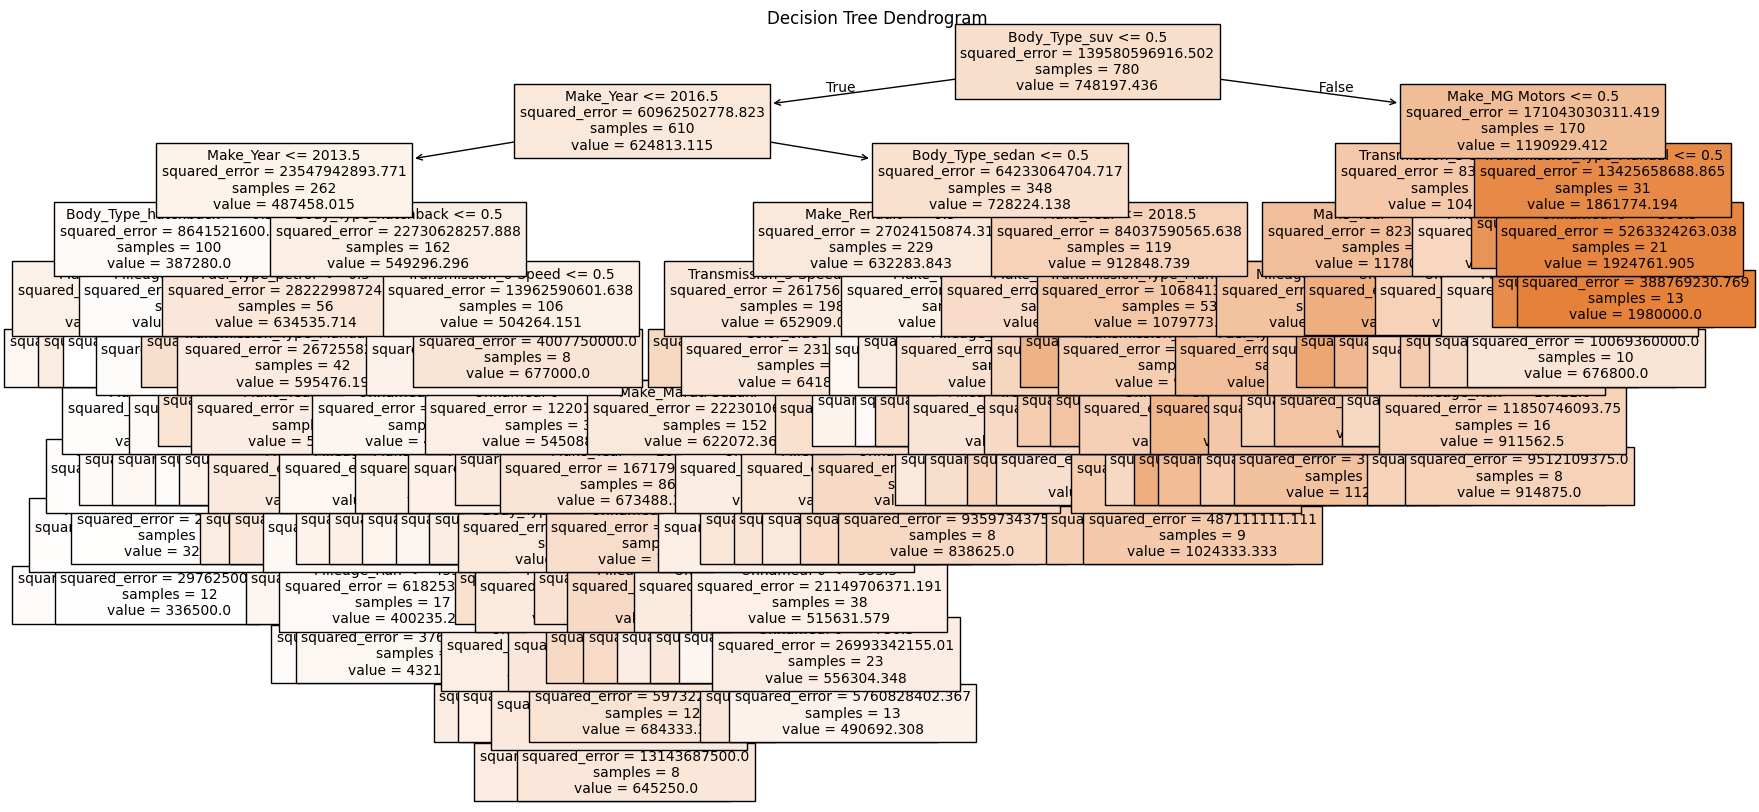

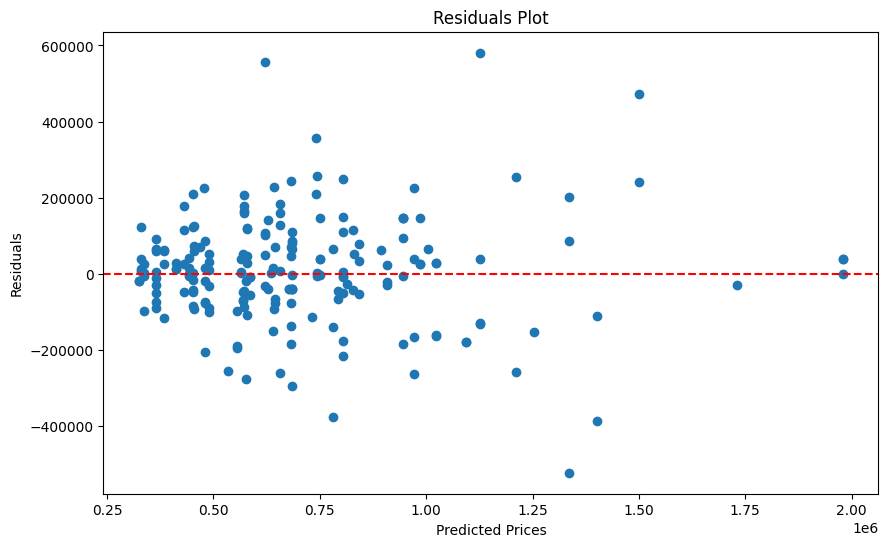

Residuals mean: 8443.816132846745


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error


tree = DecisionTreeRegressor(min_samples_leaf=best_min_samples_leaf, random_state=42)
tree.fit(X_train, y_train)


y_pred_tree = tree.predict(X_test)


r2_tree = r2_score(y_test, y_pred_tree)
rmse_tree = np.sqrt(mean_squared_error(y_test, y_pred_tree))


plt.figure(figsize=(20, 10))
plot_tree(tree, filled=True, feature_names=X.columns, fontsize=10)
plt.title("Decision Tree Dendrogram")
plt.show()


residuals = y_test - y_pred_tree
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_tree, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals Plot")
plt.xlabel("Predicted Prices")
plt.ylabel("Residuals")
plt.show()


print(f"Residuals mean: {residuals.mean()}")


Not centered around zero

In [ ]:
from sklearn.linear_model import LinearRegression


lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_pred_lin_reg = lin_reg.predict(X_test)


r2_lin_reg = r2_score(y_test, y_pred_lin_reg)
rmse_lin_reg = np.sqrt(mean_squared_error(y_test, y_pred_lin_reg))


print(f"Linear Regression R^2: {r2_lin_reg}")
print(f"Linear Regression RMSE: {rmse_lin_reg}")


if r2_tree > r2_lin_reg:
    print("The decision tree performs better.")
else:
    print("The linear regression model performs better.")


Linear Regression R^2: 0.8163910583949168
Linear Regression RMSE: 145117.5942619849
The decision tree performs better.


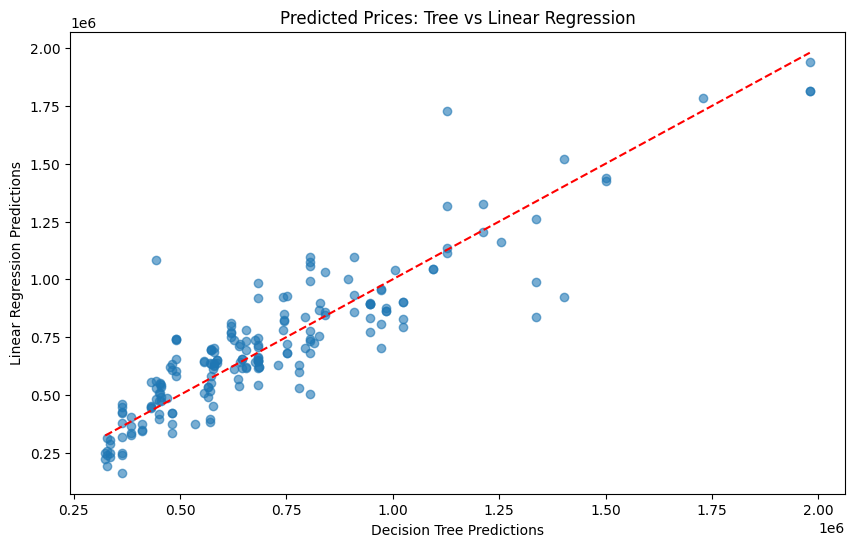

In [ ]:

y_pred_tree = tree.predict(X_test)
y_pred_lin_reg = lin_reg.predict(X_test)


plt.figure(figsize=(10, 6))
plt.scatter(y_pred_tree, y_pred_lin_reg, alpha=0.6)
plt.plot([min(y_pred_tree), max(y_pred_tree)], [min(y_pred_tree), max(y_pred_tree)], color='red', linestyle='--')
plt.title("Predicted Prices: Tree vs Linear Regression")
plt.xlabel("Decision Tree Predictions")
plt.ylabel("Linear Regression Predictions")
plt.show()


Linear Relationship: The clustering of points near the red dashed line suggests a relatively linear relationship between the two models' predictions. This could be caused if the underlying data does not have significant non-linear complexities, or both models are approximating the same relationships.

Disagreement on Extreme Values: If there are a few points far from the line, it could indicate that the decision tree is handling non-linearities or complex interactions better than linear regression

**Q5.** This is a case study about detecting fraud using classification trees. The goal is to predict the `class` variable, which is 0 for non-fraud and 1 for fraud.

1. Open `./data/creditcard_fraud.csv`. Print the number of observations and variables, and look at the first few rows of data. The variables are already normalized and de-identified, and are just called things like `V8` to protect the privacy of the clients.

2. Print a table of counts for the `class` variable and make a histogram. What percentage of transactions are fraudulent?

3. Drop `Time` and make a decision tree classifier to predict fraud. Print a confusion table and compute the accuracy. This is a serious **class imbalance** problem: The minority class is so small that essentially predicting 0's for all cases will achieve an extremely high accuracy. There are over-sampling techniques to deal with this issue, but we don't have time to cover them in class.

4. Imagine that you block every transaction in the test set labelled as fraudulent. How much money is (1) saved that should be saved, (2) lost to fraud anyway, (3) withheld in error from customers? Does implementing this anti-fraud system seem like a good idea, or not? Why?

5. Instead of predicting fraud, predict loss: Multiple the `Class` variable times the `Amount` variable, and call it `Loss`. Predict it using a decision tree regressor (making sure to drop Class, Time, and Loss from the features/covariates/predictors). What $R^2$ and RMSE do you get? Make a scatterplot of the predicted values on the test group versus the actual test values. Do you notice any interesting patterns? How could you use this algorithm to decide which transactions to block, and why?


In [ ]:
import pandas as pd
import glob


parquet_files = glob.glob('./data/creditcard_fraud_*.parquet')


df = pd.concat([pd.read_parquet(file) for file in parquet_files], ignore_index=True)


print(f"Number of observations: {df.shape[0]}")
print(f"Number of variables: {df.shape[1]}")


print("\nFirst few rows of the data:")
print(df.head())


Number of observations: 284807
Number of variables: 31

First few rows of the data:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0     0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1     0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2     1 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3     1 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4     2 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0


Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64


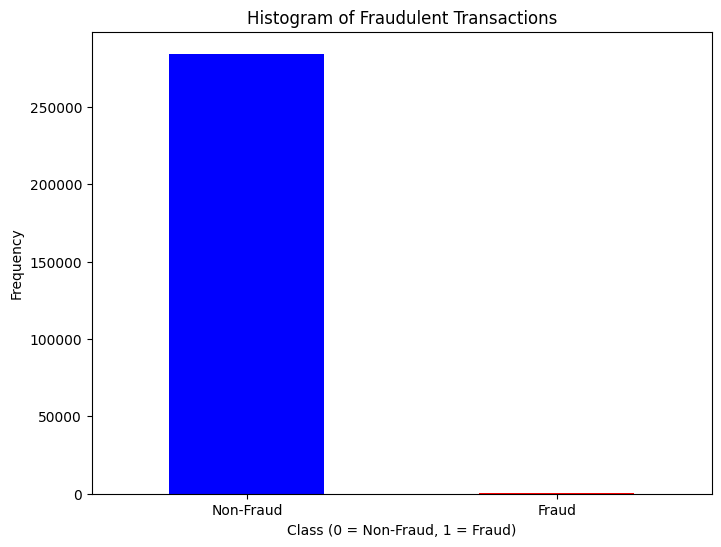


Percentage of fraudulent transactions: 0.17%


In [ ]:
import matplotlib.pyplot as plt


class_counts = df['Class'].value_counts()
print("\nClass distribution:")
print(class_counts)


plt.figure(figsize=(8, 6))
df['Class'].value_counts().plot(kind='bar', color=['blue', 'red'])
plt.title('Histogram of Fraudulent Transactions')
plt.xlabel('Class (0 = Non-Fraud, 1 = Fraud)')
plt.ylabel('Frequency')
plt.xticks([0, 1], ['Non-Fraud', 'Fraud'], rotation=0)
plt.show()

fraud_percentage = class_counts[1] / class_counts.sum() * 100
print(f"\nPercentage of fraudulent transactions: {fraud_percentage:.2f}%")


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score


X = df.drop(columns=['Class', 'Time'])
y = df['Class']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)


y_pred = dt_classifier.predict(X_test)

conf_matrix = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

print("\nConfusion Matrix:")
print(conf_matrix)
print(f"\nAccuracy: {accuracy:.4f}")



Confusion Matrix:
[[56863    15]
 [   21    63]]

Accuracy: 0.9994


In [14]:

df_test = X_test.copy()
df_test['Class'] = y_test
df_test['Amount'] = X_test['Amount']


saved_money = df_test[df_test['Class'] == 1]['Amount'].sum()  # Fraudulent transactions
lost_money = df_test[(df_test['Class'] == 1) & (y_pred == 1)]['Amount'].sum()  # Correctly predicted fraud
error_money = df_test[(df_test['Class'] == 0) & (y_pred == 1)]['Amount'].sum()  # Non-fraud mistakenly predicted as fraud

print(f"\nMoney saved (fraudulent transactions blocked): {saved_money:.2f}")
print(f"Money lost to fraud (correctly predicted fraud): {lost_money:.2f}")
print(f"Money withheld in error (non-fraud blocked): {error_money:.2f}")



Money saved (fraudulent transactions blocked): 11208.93
Money lost to fraud (correctly predicted fraud): 8177.68
Money withheld in error (non-fraud blocked): 2366.68


Does Implementing This Anti-Fraud System Seem Like a Good Idea?


Kinda: The system seems effective overall in preventing fraud since the money saved from fraud ($11,208.93) significantly exceeds the amount mistakenly withheld from legitimate customers ($2,366.68). However, the balance between saving money and customer satisfaction needs to be considered. In real-world applications, we have to consider false positives and create a system that would minimize it


R^2 for Loss prediction: 0.5450
RMSE for Loss prediction: 8.2220


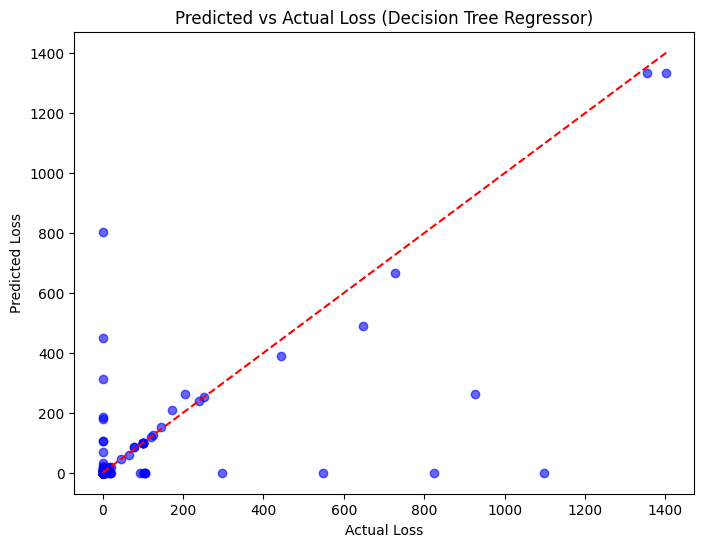

In [17]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error


df['Loss'] = df['Class'] * df['Amount']

X = df.drop(columns=['Class', 'Time', 'Loss'])
y = df['Loss']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


dt_regressor = DecisionTreeRegressor(random_state=42)
dt_regressor.fit(X_train, y_train)


y_pred_loss = dt_regressor.predict(X_test)


r2_loss = dt_regressor.score(X_test, y_test)

mse_loss = mean_squared_error(y_test, y_pred_loss)
rmse_loss = np.sqrt(mse_loss)

print(f"\nR^2 for Loss prediction: {r2_loss:.4f}")
print(f"RMSE for Loss prediction: {rmse_loss:.4f}")


plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_loss, alpha=0.6, color='b')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='r', linestyle='--')
plt.title('Predicted vs Actual Loss (Decision Tree Regressor)')
plt.xlabel('Actual Loss')
plt.ylabel('Predicted Loss')
plt.show()
